In [44]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

os.chdir("/Users/wtorres/Documents/hpc-tools/derecho")
from submit_jobs import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Theory: Linear Energy Flux w/ Rotation

\begin{align}
F_h &= \frac{ \rho_0 H A^2 \omega m^2}{4k^3} (\omega^2 - f^2)\cos{\theta} \\
\end{align}

Using the following for nondimensionalization

$Fr = Ak$, $Ro = \frac{\omega}{f}$, $\alpha = \Lambda\frac{m}{k}$

assuming a reference energy flux

$$\mathcal{F_0} = \frac{\rho H \omega_0^3}{4m^3}$$

gives

$$ \tilde{\mathcal{F}} = \frac{\mathcal{F}}{\mathcal{F_0}} = Fr^2 \bigg( \frac{\alpha}{\Lambda} \bigg)^5 (1 - {Ro}^{-2})\cos{\theta} $$

combining $Fr$ and $\alpha$ into an amplitude parameter

$$\epsilon = Am = Fr \frac{\alpha}{\Lambda}$$ 

(for M1 tide, $\epsilon = \pi\frac{A}{H}$) gives

$$ \tilde{\mathcal{F}} = \frac{\mathcal{F}}{\mathcal{F_0}} = \epsilon^2 \bigg( \frac{\alpha}{\Lambda} \bigg)^3 (1 - {Ro}^{-2})\cos{\theta} $$

which can be re-expanded for the purpose of planning simulations

$$ \tilde{\mathcal{F}} = \frac{\mathcal{F}}{\mathcal{F_0}} = (Am)^2 \bigg( \frac{m}{k} \bigg)^3 (1 - \frac{f^2}{\omega_0^2})\cos{\theta} $$

for mode-1 waves $m_1 = \frac{\pi}{H}$

$$ \tilde{\mathcal{F}} = \frac{\mathcal{F}}{\mathcal{F_0}} = A^2 k^{-3} \bigg( \frac{\pi}{H} \bigg) ^5  \bigg( 1 - \frac{f^2}{\omega_0^2} \bigg)\cos{\theta} $$

## Compute parameter space

In [128]:
from physics import solve_flux_variable, 

ω = 2*np.pi / (3600*12.42/2) #M1 tidal period
f = 1e-5
theta = math.radians(30)
amplitudes = [4,8,12,16,20]

k = np.array(
    [solve_flux_variable(flux_ratio = 21000, H = 100, omega = ω, theta = theta,
    k = None, f = f, A = x) for x in amplitudes]
    )

display(f"k = { np.round(2*np.pi*k**(-1))}")
display(f"k = { np.round(2*np.pi*k**(-1))}")

'k = [23084. 14542. 11097.  9161.  7894.]'

## Setup Project Folder

In [16]:
file_path = Path("/Users/wtorres/Desktop/suntans.dat")
vary_param(file_path, "Coriolis_f", 0.0002)
vary_param(file_path, "amp", 0.0002)

  Coriolis_f           → 0.0002


In [1]:
# build_grid(file_path,file_path)

## Grid

In [27]:
from grid import generate_grid, domain_width_from_wave, read_points

W = domain_width_from_wave(k = k, theta_deg = 30.0, n_waves=1)

Matplotlib is building the font cache; this may take a moment.


20000.000000000004

In [26]:
generate_grid(datadir="rundata", Nx = 200, Ny = 130, L = 4000.0, W = W)

Grid written to rundata/
  Cells : 26000  (200 x 130)
  Points: 26331  (201 x 131)
  Edges : 52130
  dx = 20.0000 m,  dy = 153.8462 m


## Plotting

In [36]:
X,Y = read_points("rundata/points.dat",  Nx=200, Ny=130)

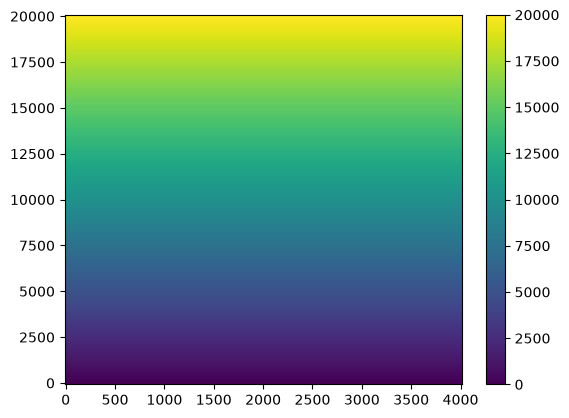

In [40]:
# plt.close("all")
# plt.pcolormesh(X,Y,Y)
# plt.colorbar()